# tACS Bandit EEG Analyses

Tier 2 EEG analysis notebook for: *Examining the effects of theta-tACS over left DLPFC on reward-based learning across the adult lifespan*

This notebook handles artifact removal, spectral parameterization, individual theta frequency (ITF) extraction, and cross-run comparisons. It imports shared configuration from the behavioral analysis notebook and operates on NIC2 output files (.easy, .info, _IMP.txt).

**Key limitations for first 4 participants:**
- No CMS/DRL Earclip reference electrode → software average re-referencing applied
- Stimulation channels (F3, Fp1, FCz, FT7) blanked by NIC2 on all runs
- Only 3 EEG-only channels available (F4, P4, P3)
- LSL task markers not reaching NIC2 trigger channel

## 0. Setup and Configuration

In [1]:
import os
import glob
import warnings
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import signal, stats
from pathlib import Path
from specparam import SpectralModel

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', message='loadtxt: input contained no data')

# --- Path configuration ---
REPO_ROOT = Path('..').resolve()
EEG_DIR = REPO_ROOT / 'data' / 'nic' / 'raw'

# --- Subject tracker ---
# Mirrors the behavioral notebook's SUBJECT_INFO with EEG-specific flags
SUBJECT_INFO = {
    '10886': {'counterbalance': 'B', 'earclip': False},
    '10998': {'counterbalance': 'B', 'earclip': False},
    '11773': {'counterbalance': 'B', 'earclip': False},
    '10656': {'counterbalance': 'A', 'earclip': False},
}

# --- Run structure ---
# Maps run number to condition for each counterbalance order.
# Order A: Active on runs 2-3, Sham on runs 6-7
# Order B: Sham on runs 2-3, Active on runs 6-7
# Runs 1,5 = baseline; Runs 4,8 = post-stimulation baseline
RUN_CONDITIONS = {
    'A': {1: 'baseline', 2: 'active', 3: 'active', 4: 'post',
          5: 'baseline', 6: 'sham', 7: 'sham', 8: 'post'},
    'B': {1: 'baseline', 2: 'sham', 3: 'sham', 4: 'post',
          5: 'baseline', 6: 'active', 7: 'active', 8: 'post'},
}

# --- EEG constants ---
FS = 500                    # Sampling rate (Hz)
CH_LABELS = ['F3', 'Fp1', 'FCz', 'FT7', 'F4', 'P4', 'P3', 'Ch8']
STIM_CH_IDX = [0, 1, 2, 3]  # Channels used for stimulation (blanked by NIC2)
EEG_CH_IDX = [4, 5, 6]      # EEG-only recording channels
EEG_CH_LABELS = ['F4', 'P4', 'P3']
TACS_FREQ = 6.0             # Stimulation frequency (Hz)

# --- Frequency band definitions ---
# Standard clinical/research bands
BANDS = {
    'delta': (1, 4),
    'theta': (4, 8),
    'alpha': (8, 13),
    'beta':  (13, 30),
    'gamma': (30, 50),
}

print(f'Repository root: {REPO_ROOT}')
print(f'EEG directory: {EEG_DIR}')
print(f'Subjects in tracker: {list(SUBJECT_INFO.keys())}')

Repository root: /Users/jameswyngaarden/Documents/GitHub/tacs_bandit
EEG directory: /Users/jameswyngaarden/Documents/GitHub/tacs_bandit/data/nic/raw
Subjects in tracker: ['10886', '10998', '11773', '10656']


## 1. Data Loading Utilities

Functions for loading NIC2 files, detecting run conditions, and applying software re-referencing.

In [24]:
# =============================================================================
# 1. NIC2 File Loading & Preprocessing Utilities
# =============================================================================

def load_nic2_run(easy_path, info_path=None, imp_path=None):
    """
    Load a single NIC2 recording.
    
    .easy file structure (tab-delimited, no header):
        Columns 0-7:  8 EEG channels in nanovolts (nV)
        Column 11:    Trigger/marker channel
        Column 12:    Timestamp (Unix epoch, milliseconds)
    
    .info file: XML-like metadata with montage, sampling rate, stim params.
    _IMP.txt: Impedance values (ohms) for each channel over time.
    
    Returns dict with parsed data and metadata.
    """
    raw = np.loadtxt(easy_path)
    eeg = raw[:, :8]
    triggers = raw[:, 11] if raw.shape[1] > 11 else np.zeros(len(raw))
    timestamps = raw[:, 12] if raw.shape[1] > 12 else np.arange(len(raw))
    
    # Parse .info
    info = {}
    if info_path and Path(info_path).exists():
        with open(info_path, 'r') as f:
            info_text = f.read()
        for line in info_text.split('\n'):
            if 'EEG sampling rate' in line and 'Samples' in line:
                info['fs'] = int(line.split(':')[1].strip().split()[0])
            if 'Step name' in line:
                info['step_name'] = line.split(':')[1].strip()
            # Parse tACS amplitude to determine if active
            if 'Atacs (uA)' in line:
                val = int(line.split(':')[1].strip())
                if val > 0:
                    info['has_active_stim'] = True
    
    fs = info.get('fs', FS)
    stim_mask = (eeg[:, 0] == -1)
    
    # Load impedance
    impedance = None
    if imp_path and Path(imp_path).exists():
        try:
            imp_raw = np.loadtxt(imp_path)
            if imp_raw.ndim == 2 and imp_raw.shape[0] > 0:
                impedance = {'values': imp_raw[:, :8], 'timestamps': imp_raw[:, 8]}
        except Exception:
            pass
    
    return {
        'eeg': eeg, 'timestamps': timestamps, 'triggers': triggers,
        'fs': fs, 'stim_mask': stim_mask, 'impedance': impedance, 'info': info,
    }


def avg_rereference(eeg, ch_indices=EEG_CH_IDX):
    """
    Average re-reference across specified channels.
    
    WHY: Without a hardware reference (Earclip), all channels share a
    floating reference that introduces a large common-mode signal. By
    computing the mean across channels and subtracting it, we remove
    this shared component, isolating spatially specific activity.
    
    LIMITATION: With only 3 channels, each channel constitutes 1/3 of
    the average, so subtracting it can attenuate real signals and create
    mathematical dependencies between channels. Interpret spatial
    differences cautiously.
    
    Parameters
    ----------
    eeg : ndarray (samples x channels), nanovolts
    ch_indices : which columns to use for re-referencing
    
    Returns
    -------
    eeg_reref : ndarray (samples x len(ch_indices)), nanovolts
    """
    subset = eeg[:, ch_indices].astype(float)
    avg = np.mean(subset, axis=1, keepdims=True)
    return subset - avg


def detect_active_stim(eeg, stim_mask, fs=FS):
    """
    Detect whether a run has SUSTAINED active tACS (not just a sham ramp).
    
    PREVIOUS BUG: The old version computed 6 Hz power across the whole
    run. Even a brief sham ramp (~30-45s) produces enough artifact to
    dominate the average PSD, causing false positives.
    
    FIX: We now check whether 6 Hz power is elevated in the MIDDLE of
    the run (60-300s), not just at the edges where sham ramps occur.
    Active stimulation shows sustained high power throughout; sham shows
    high power only in the first/last ~45 seconds.
    
    Returns True only if sustained active stimulation is detected.
    """
    if np.sum(stim_mask) < 2048:
        return False
    
    ch_data = eeg[:, EEG_CH_IDX[0]]  # F4
    
    # Compute time-resolved 6 Hz power using a spectrogram
    f, t_spec, Sxx = signal.spectrogram(
        signal.detrend(ch_data), fs=fs,
        nperseg=1000, noverlap=750, scaling='density'
    )
    
    six_hz = (f >= 5.5) & (f <= 6.5)
    six_hz_power = 10 * np.log10(np.mean(Sxx[six_hz, :], axis=0) + 1e-30)
    
    # Check the MIDDLE of the run (60-300s) to avoid sham ramps
    # Sham: ramp in first ~45s, nothing in middle
    # Active: sustained high power throughout including middle
    middle_mask = (t_spec >= 60) & (t_spec <= 300)
    
    if np.sum(middle_mask) == 0:
        return False
    
    middle_power = np.mean(six_hz_power[middle_mask])
    
    # Baseline 6 Hz power is typically ~88-90 dB
    # Active stimulation pushes it to ~150+ dB
    # Threshold at 120 dB provides wide margin
    return middle_power > 120


def discover_runs(eeg_dir, subject_id):
    """
    Find all NIC2 files for a subject and organize by run number.
    
    Handles duplicate files (false starts) by preferring the longest
    recording for each run number.
    
    Returns dict: {run_number: {'easy': path, 'info': path, 'imp': path}}
    """
    pattern = str(eeg_dir / f'*sub-{subject_id}_Run*')
    all_files = glob.glob(pattern + '.easy')
    
    runs = {}
    for easy_path in sorted(all_files):
        easy_path = Path(easy_path)
        fname = easy_path.stem
        
        # Extract run number from filename
        try:
            run_str = fname.split('Run')[1].strip().split('_')[0].strip()
            run_num = int(run_str)
        except (IndexError, ValueError):
            continue
        
        # Find matching .info and _IMP.txt
        # Timestamp prefix may differ between .easy and _IMP.txt
        info_path = easy_path.with_suffix('.info')
        
        # IMP files use a slightly different timestamp sometimes
        imp_candidates = list(eeg_dir.glob(f'*sub-{subject_id}_Run*{run_num}_IMP.txt'))
        imp_path = imp_candidates[0] if imp_candidates else None
        
        # Get file size to prefer longer recordings over false starts
        file_size = easy_path.stat().st_size
        
        if run_num not in runs or file_size > runs[run_num]['size']:
            runs[run_num] = {
                'easy': easy_path,
                'info': info_path if info_path.exists() else None,
                'imp': imp_path,
                'size': file_size,
            }
    
    # Remove the size key before returning
    for run in runs.values():
        del run['size']
    
    return runs


print('Utilities loaded.')

Utilities loaded.


## 2. Batch Load All Runs for a Subject

Discover and load all available NIC2 files, tag each with its condition based on counterbalance order, and apply preprocessing (re-referencing for no-earclip participants).

In [27]:
# =============================================================================
# 2. Batch Load All Runs for One Subject
# =============================================================================

SUBJECT_ID = '10886'  # Change this to process a different subject

sub_info = SUBJECT_INFO[SUBJECT_ID]
cb_order = sub_info['counterbalance']
has_earclip = sub_info['earclip']
condition_map = RUN_CONDITIONS[cb_order]

print(f'Subject: sub-{SUBJECT_ID}')
print(f'Counterbalance: Order {cb_order}')
print(f'Earclip: {"Yes" if has_earclip else "No ⚠"}')
print(f'Expected run order: {condition_map}')
print()

# Discover available files
run_files = discover_runs(EEG_DIR, SUBJECT_ID)
print(f'Found {len(run_files)} runs: {sorted(run_files.keys())}')
print()

# Load each run
all_runs = {}
for run_num in sorted(run_files.keys()):
    files = run_files[run_num]
    print(f'--- Run {run_num} ({condition_map.get(run_num, "?")}) ---')
    
    nic2 = load_nic2_run(
        easy_path=files['easy'],
        info_path=files['info'],
        imp_path=files['imp'],
    )
    
    # Tag with condition and metadata
    nic2['run_num'] = run_num
    nic2['condition'] = condition_map.get(run_num, 'unknown')
    nic2['has_earclip'] = has_earclip
    nic2['is_active'] = detect_active_stim(nic2['eeg'], nic2['stim_mask'])
    
    duration = (nic2['timestamps'][-1] - nic2['timestamps'][0]) / 1000
    pct_blanked = 100 * np.sum(nic2['stim_mask']) / len(nic2['stim_mask'])
    
    print(f'  Duration: {duration:.1f}s, Blanked: {pct_blanked:.1f}%')
    print(f'  Condition: {nic2["condition"]}, Active stim detected: {nic2["is_active"]}')
    
    # Sanity check: does detected stim match expected condition?
    expected_active = nic2['condition'] == 'active'
    if nic2['is_active'] != expected_active:
        print(f'  ⚠ MISMATCH: expected {"active" if expected_active else "no"} stim, '
              f'detected {"active" if nic2["is_active"] else "none"}')
    
    # Apply re-referencing if no earclip
    if not has_earclip:
        nic2['eeg_reref'] = avg_rereference(nic2['eeg'])
    else:
        # With earclip, just extract the EEG-only channels as-is
        nic2['eeg_reref'] = nic2['eeg'][:, EEG_CH_IDX].astype(float)
    
    all_runs[run_num] = nic2
    print()

print(f'Loaded {len(all_runs)} runs for sub-{SUBJECT_ID}')

Subject: sub-10886
Counterbalance: Order B
Earclip: No ⚠
Expected run order: {1: 'baseline', 2: 'sham', 3: 'sham', 4: 'post', 5: 'baseline', 6: 'active', 7: 'active', 8: 'post'}

Found 8 runs: [1, 2, 3, 4, 5, 6, 7, 8]

--- Run 1 (baseline) ---
  Duration: 361.4s, Blanked: 99.8%
  Condition: baseline, Active stim detected: False

--- Run 2 (sham) ---
  Duration: 361.2s, Blanked: 99.8%
  Condition: sham, Active stim detected: False

--- Run 3 (sham) ---
  Duration: 361.1s, Blanked: 99.7%
  Condition: sham, Active stim detected: False

--- Run 4 (post) ---
  Duration: 361.2s, Blanked: 99.8%
  Condition: post, Active stim detected: False

--- Run 5 (baseline) ---
  Duration: 361.7s, Blanked: 99.6%
  Condition: baseline, Active stim detected: False

--- Run 6 (active) ---
  Duration: 361.6s, Blanked: 99.7%
  Condition: active, Active stim detected: True

--- Run 7 (active) ---
  Duration: 361.3s, Blanked: 99.7%
  Condition: active, Active stim detected: True

--- Run 8 (post) ---
  Duration

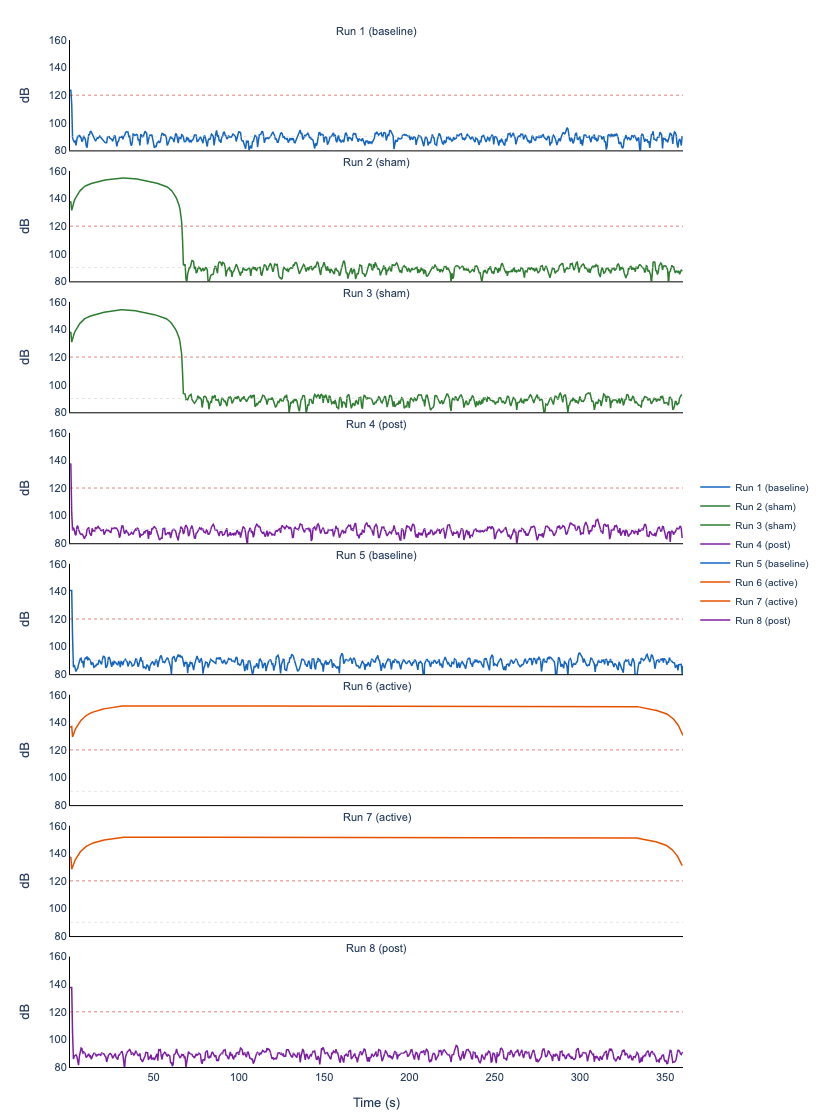


sub-10886 — 6 Hz Power Summary (F4)
 Run  Condition  First 45s     Middle   Last 45s    Stim?
-------------------------------------------------------
   1   baseline      90.0      88.9      88.4     NONE
   2       sham     151.1      90.2      88.7     SHAM
   3       sham     150.2      90.0      88.6     SHAM
   4       post      89.9      88.9      88.7     NONE
   5   baseline      90.2      88.3      88.2     NONE
   6     active     147.7     151.7     148.2   ACTIVE
   7     active     147.6     151.4     147.9   ACTIVE
   8       post      90.3      88.8      88.0     NONE


In [29]:
# =============================================================================
# 2b. 6 Hz Stimulation Artifact Timecourse — Verify Active vs Sham
# =============================================================================
#
# WHY THIS MATTERS:
# A whole-run PSD cannot distinguish sustained active stimulation from
# a brief sham ramp — even 30-45 seconds of artifact at 60+ dB above
# background dominates the Welch average. This time-resolved plot shows
# 6 Hz power in 2-second windows across each run, making the difference
# between sham (brief spike at start) and active (sustained plateau)
# immediately visible.
#
# HOW TO READ:
# - Baseline (~88-90 dB): no stimulation artifact, just background EEG
# - Sham ramp (~150 dB for ~30-45s, then back to baseline): protocol
#   delivers brief ramp-up/ramp-down to mimic active sensation
# - Active (~150-152 dB sustained for full 6 min): real stimulation
# - The 30s ramp-up and ramp-down periods are visible as slopes at the
#   start and end of active runs
#
# This plot also serves as a protocol compliance check — if a "sham" run
# shows sustained 6 Hz power, the wrong protocol was loaded in NIC2.

from scipy import signal as sig

available_runs = sorted(all_runs.keys())
n_runs = len(available_runs)

fig = make_subplots(
    rows=n_runs, cols=1, shared_xaxes=True, vertical_spacing=0.02,
    subplot_titles=[f'Run {r} ({all_runs[r]["condition"]})'
                    for r in available_runs],
)

condition_colors = {
    'baseline': '#1565C0',
    'sham':     '#2E7D32',
    'active':   '#E65100',
    'post':     '#7B1FA2',
}

for i, run_num in enumerate(available_runs):
    nic2 = all_runs[run_num]
    condition = nic2['condition']
    eeg = nic2['eeg'][:, EEG_CH_IDX[0]]  # F4
    
    # Spectrogram: 2-second windows, 0.5s step
    f, t_spec, Sxx = sig.spectrogram(
        sig.detrend(eeg), fs=FS,
        nperseg=1000, noverlap=750, scaling='density',
    )
    
    # Extract 6 Hz band power over time
    six_hz = (f >= 5.5) & (f <= 6.5)
    six_hz_power = 10 * np.log10(np.mean(Sxx[six_hz, :], axis=0) + 1e-30)
    
    color = condition_colors.get(condition, '#999999')
    
    fig.add_trace(go.Scatter(
        x=t_spec, y=six_hz_power,
        mode='lines', line=dict(color=color, width=1.5),
        name=f'Run {run_num} ({condition})',
        hovertemplate='%{x:.0f}s: %{y:.1f} dB<extra></extra>',
    ), row=i+1, col=1)
    
    # Baseline reference line (typical background level)
    fig.add_hline(y=90, line=dict(color='#CCCCCC', width=0.5, dash='dot'),
                  row=i+1, col=1)
    
    # Active threshold reference
    fig.add_hline(y=120, line=dict(color='#CC0000', width=0.5, dash='dot'),
                  row=i+1, col=1)
    
    fig.update_yaxes(range=[80, 160], title_text='dB', row=i+1, col=1)

fig.update_xaxes(title_text='Time (s)', row=n_runs, col=1)

fig.update_layout(
    height=140 * n_runs, width=900,
    template='plotly_white',
    margin=dict(l=70, r=40, t=40, b=50),
    font=dict(family='Arial', size=11),
    legend=dict(x=1.02, y=0.5, font=dict(size=10)),
)

for ann in fig.layout.annotations:
    ann.update(font_size=11)

fig.update_xaxes(showgrid=False, showline=True, linewidth=1, linecolor='black')
fig.update_yaxes(showgrid=False, showline=True, linewidth=1, linecolor='black')

fig.show(config=dict(toImageButtonOptions=dict(
    filename=f'six_hz_timecourse_sub-{SUBJECT_ID}')))

# ---- Print summary table ----
print(f'\nsub-{SUBJECT_ID} — 6 Hz Power Summary (F4)')
print(f'{"Run":>4} {"Condition":>10} {"First 45s":>10} {"Middle":>10} {"Last 45s":>10} {"Stim?":>8}')
print('-' * 55)
for run_num in available_runs:
    nic2 = all_runs[run_num]
    eeg = nic2['eeg'][:, EEG_CH_IDX[0]]
    f, t_spec, Sxx = sig.spectrogram(
        sig.detrend(eeg), fs=FS, nperseg=1000, noverlap=750, scaling='density')
    six_hz = (f >= 5.5) & (f <= 6.5)
    p = 10 * np.log10(np.mean(Sxx[six_hz, :], axis=0) + 1e-30)
    
    duration = t_spec[-1]
    early = np.mean(p[t_spec <= 45])
    middle = np.mean(p[(t_spec >= 60) & (t_spec <= 300)])
    late = np.mean(p[t_spec >= (duration - 45)])
    
    # Classify based on middle-run power
    if middle > 120:
        stim_label = 'ACTIVE'
    elif early > 120:
        stim_label = 'SHAM'
    else:
        stim_label = 'NONE'
    
    print(f'{run_num:>4} {nic2["condition"]:>10} {early:>9.1f} {middle:>9.1f} {late:>9.1f} {stim_label:>8}')

## 3. Spectral Parameterization (specparam/FOOOF)

### What is spectral parameterization?

A raw PSD contains two mixed components:
1. **Aperiodic (1/f) component** — broadband power that decreases with frequency following a power law. This reflects the overall "background" neural noise and is not specific to any oscillation.
2. **Periodic (oscillatory) peaks** — bumps *above* the 1/f background that reflect genuine rhythmic neural activity (e.g., theta at ~6 Hz, alpha at ~10 Hz).

When we simply look for the "peak" within the 4–8 Hz theta band, we often find it at the lowest frequency (e.g., 4.2 Hz) because the 1/f slope is steepest there — not because there's actual theta oscillatory activity at 4.2 Hz.

**specparam** (formerly called FOOOF: "Fitting Oscillations & One-Over-F") solves this by:
1. Fitting the 1/f aperiodic component as a power law: $P(f) = b - \log(f^\chi)$ where $b$ is the offset and $\chi$ is the exponent
2. Subtracting the 1/f fit to get the "flattened" spectrum
3. Detecting peaks in the flattened spectrum that rise above a threshold
4. Fitting each peak as a Gaussian: center frequency, power, bandwidth

The **center frequency** of a peak in the theta range is the Individual Theta Frequency (ITF) — a more reliable estimate than raw peak-picking.

### Parameters we use:
- `peak_width_limits=(1, 8)`: peaks must be 1–8 Hz wide (excludes very narrow artifact spikes and very broad non-oscillatory features)
- `max_n_peaks=6`: allow up to 6 peaks in the 1–50 Hz range
- `min_peak_height=0.1`: peaks must be at least 0.1 log-units above the 1/f background (conservative threshold to avoid false positives)
- `aperiodic_mode='fixed'`: assumes a single power law (appropriate for our narrow frequency range; `'knee'` mode is for very broadband data)

In [32]:
# =============================================================================
# 3. Spectral Parameterization — Extract ITF from Baseline Runs
# =============================================================================
#
# PIPELINE:
# 1. For each run:
#    a. Extract re-referenced EEG-only channels
#    b. Compute Welch PSD
#    c. Fit specparam model to separate 1/f from oscillatory peaks
#    d. Extract theta-range peak (if present) as ITF estimate
# 2. Report ITF for each channel and run
# 3. Flag active runs where theta peaks are likely artifact
#
# SPECPARAM API (v2.x):
#   model.data.freqs              → frequency axis
#   model.data.power_spectrum     → log-power PSD
#   model.results.params.aperiodic.params → [offset, exponent]
#   model.results.params.periodic.params  → Nx3 array [center, power, bandwidth]
#   model.results.model.modeled_spectrum  → full model fit
#   model.results.metrics.results['gof_rsquared'] → R²

from specparam import SpectralModel

def compute_aperiodic_fit(freqs, aperiodic_params):
    """
    Reconstruct the aperiodic (1/f) component from fitted parameters.
    
    For 'fixed' mode (no knee):
        log(P) = offset - exponent * log10(freq)
    
    This is the 1/f "background" line that we subtract from the PSD
    to reveal oscillatory peaks.
    """
    offset, exponent = aperiodic_params
    return offset - np.log10(freqs ** exponent)


def compute_psd(eeg_data, fs=FS, nperseg=2048):
    """
    Compute power spectral density using Welch's method.
    
    WHY WELCH'S METHOD: Divides the signal into overlapping segments,
    computes a periodogram for each, and averages them. This reduces
    noise in the spectral estimate at the cost of frequency resolution.
    With nperseg=2048 at 500 Hz, we get ~0.24 Hz resolution and
    ~4-second windows, which is sufficient for resolving theta (4-8 Hz)
    and alpha (8-13 Hz) peaks.
    """
    data = signal.detrend(eeg_data.astype(float))
    freqs, psd = signal.welch(data, fs=fs, nperseg=nperseg, noverlap=nperseg//2)
    return freqs, psd


def fit_specparam(freqs, psd, freq_range=(1, 50)):
    """
    Fit a specparam model to a PSD.
    
    Returns the fitted SpectralModel object. Key results accessed via:
      .results.params.periodic.params    → peak parameters (Nx3)
      .results.params.aperiodic.params   → 1/f parameters (2,)
      .results.metrics.results['gof_rsquared'] → goodness of fit
    """
    sm = SpectralModel(
        peak_width_limits=(1, 8),
        max_n_peaks=6,
        min_peak_height=0.1,
        aperiodic_mode='fixed',
        verbose=False,
    )
    sm.fit(freqs, psd, freq_range)
    return sm


def extract_itf(model, theta_range=(4, 8)):
    """
    Extract individual theta frequency from a fitted specparam model.
    
    Searches the detected peaks for one whose center frequency falls
    within the theta range. If multiple theta peaks are found, returns
    the one with the highest power.
    """
    peaks = model.results.params.periodic.params  # Nx3: [center, power, bandwidth]
    
    if peaks.ndim == 1:
        # Only one peak — reshape to 2D
        if len(peaks) == 0:
            return {'itf': None, 'power': None, 'bandwidth': None, 'has_theta': False}
        peaks = peaks.reshape(1, -1)
    
    if len(peaks) == 0:
        return {'itf': None, 'power': None, 'bandwidth': None, 'has_theta': False}
    
    theta_peaks = peaks[(peaks[:, 0] >= theta_range[0]) &
                        (peaks[:, 0] <= theta_range[1])]
    
    if len(theta_peaks) == 0:
        return {'itf': None, 'power': None, 'bandwidth': None, 'has_theta': False}
    
    best = theta_peaks[np.argmax(theta_peaks[:, 1])]
    return {
        'itf': best[0],
        'power': best[1],
        'bandwidth': best[2],
        'has_theta': True,
    }


def get_model_components(model):
    """
    Extract all key components from a fitted specparam model.
    Convenience wrapper for the v2.x API.
    """
    freqs = model.data.freqs
    power_spectrum = model.data.power_spectrum
    ap_params = model.results.params.aperiodic.params
    ap_fit = compute_aperiodic_fit(freqs, ap_params)
    modeled = model.results.model.modeled_spectrum
    flattened = power_spectrum - ap_fit
    peaks = model.results.params.periodic.params
    r_squared = model.results.metrics.results['gof_rsquared']
    
    return {
        'freqs': freqs,
        'power_spectrum': power_spectrum,
        'ap_fit': ap_fit,
        'modeled_spectrum': modeled,
        'flattened': flattened,
        'peaks': peaks,
        'ap_params': ap_params,
        'r_squared': r_squared,
    }


# ---- Run specparam on all available runs ----
specparam_results = []
specparam_models = {}

for run_num, nic2 in sorted(all_runs.items()):
    condition = nic2['condition']
    is_active = nic2['is_active']
    eeg_reref = nic2['eeg_reref']
    
    print(f'=== Run {run_num} ({condition}{" · ACTIVE STIM DETECTED" if is_active else ""}) ===')
    
    for ch_i, ch_label in enumerate(EEG_CH_LABELS):
        freqs, psd = compute_psd(eeg_reref[:, ch_i])
        model = fit_specparam(freqs, psd)
        mc = get_model_components(model)
        itf_result = extract_itf(model)
        
        n_peaks = len(mc['peaks']) if mc['peaks'].ndim == 2 else (1 if len(mc['peaks']) > 0 else 0)
        
        result = {
            'run': run_num,
            'condition': condition,
            'channel': ch_label,
            'is_active_stim': is_active,
            'r_squared': mc['r_squared'],
            'aperiodic_offset': mc['ap_params'][0],
            'aperiodic_exponent': mc['ap_params'][1],
            'n_peaks': n_peaks,
            **itf_result,
        }
        specparam_results.append(result)
        specparam_models[(run_num, ch_label)] = model
        
        itf_str = f'{itf_result["itf"]:.1f} Hz' if itf_result['has_theta'] else 'none'
        artifact_flag = ' ⚠ ARTIFACT?' if (is_active and itf_result['has_theta']) else ''
        print(f'  {ch_label}: R²={mc["r_squared"]:.3f}, '
              f'1/f exp={mc["ap_params"][1]:.2f}, '
              f'{n_peaks} peaks, '
              f'ITF={itf_str}{artifact_flag}')
    print()

specparam_df = pd.DataFrame(specparam_results)
print('\n--- Summary ---')
print(specparam_df[['run', 'condition', 'channel', 'is_active_stim',
                     'r_squared', 'has_theta', 'itf']].to_string(index=False))

=== Run 1 (baseline) ===
  F4: R²=0.983, 1/f exp=1.32, 6 peaks, ITF=none
  P4: R²=0.973, 1/f exp=1.48, 5 peaks, ITF=none
  P3: R²=0.991, 1/f exp=1.53, 6 peaks, ITF=none

=== Run 2 (sham) ===
  F4: R²=0.737, 1/f exp=0.53, 6 peaks, ITF=6.0 Hz
  P4: R²=0.694, 1/f exp=0.18, 6 peaks, ITF=6.0 Hz
  P3: R²=0.740, 1/f exp=0.26, 6 peaks, ITF=6.0 Hz

=== Run 3 (sham) ===
  F4: R²=0.726, 1/f exp=0.51, 6 peaks, ITF=6.0 Hz
  P4: R²=0.687, 1/f exp=0.25, 6 peaks, ITF=6.0 Hz
  P3: R²=0.732, 1/f exp=0.23, 6 peaks, ITF=6.0 Hz

=== Run 4 (post) ===
  F4: R²=0.974, 1/f exp=0.87, 6 peaks, ITF=7.7 Hz
  P4: R²=0.974, 1/f exp=0.89, 6 peaks, ITF=none
  P3: R²=0.974, 1/f exp=0.89, 6 peaks, ITF=7.7 Hz

=== Run 5 (baseline) ===
  F4: R²=0.998, 1/f exp=1.48, 4 peaks, ITF=none
  P4: R²=0.982, 1/f exp=0.92, 5 peaks, ITF=6.6 Hz
  P3: R²=0.996, 1/f exp=1.63, 0 peaks, ITF=none

=== Run 6 (active · ACTIVE STIM DETECTED) ===
  F4: R²=0.721, 1/f exp=0.22, 6 peaks, ITF=6.0 Hz ⚠ ARTIFACT?
  P4: R²=0.608, 1/f exp=0.07, 6 peak

## 4. Specparam Model Visualization

Visualize the spectral parameterization fit for each run × channel. Shows the original PSD, the 1/f aperiodic fit, and the detected oscillatory peaks. This is critical for verifying that the model is fitting sensibly and that detected theta peaks are genuine oscillations rather than 1/f artifacts.

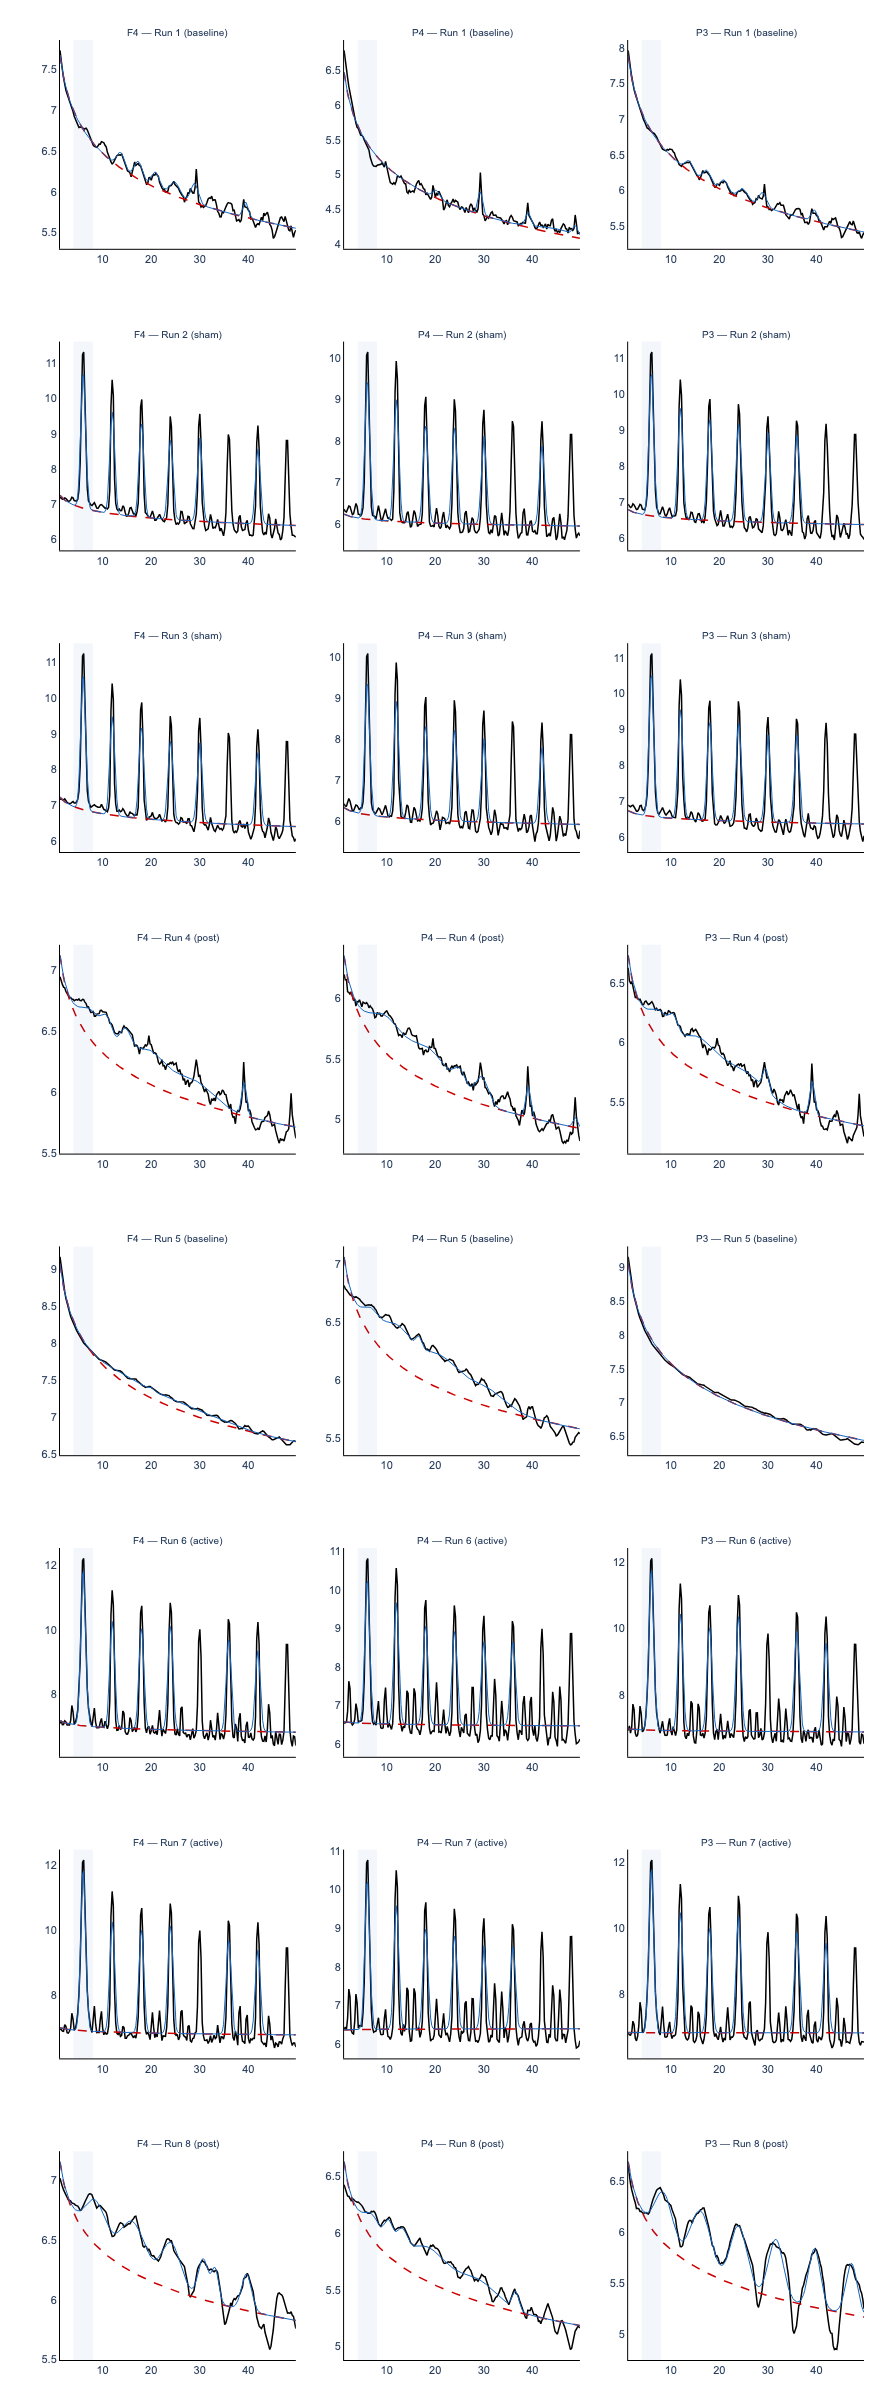

In [35]:
# =============================================================================
# 4. Specparam Fit Visualization — All Runs × Channels
# =============================================================================
#
# WHAT THIS PLOT SHOWS:
# - Black line: original PSD (log power, what we measured)
# - Red dashed line: the fitted 1/f aperiodic component
# - Blue line: full model fit (1/f + peaks)
# - Light blue shading on theta band (4-8 Hz) for reference
# - If the blue line rises above the red dashed line in theta,
#   that indicates an oscillatory peak above the 1/f background.

available_runs = sorted(all_runs.keys())
n_runs = len(available_runs)

fig = make_subplots(
    rows=n_runs, cols=3,
    subplot_titles=[f'{ch} — Run {r} ({all_runs[r]["condition"]})'
                    for r in available_runs for ch in EEG_CH_LABELS],
    vertical_spacing=0.08 if n_runs <= 4 else 0.04,
    horizontal_spacing=0.06,
)

for row_i, run_num in enumerate(available_runs):
    for col_i, ch_label in enumerate(EEG_CH_LABELS):
        model = specparam_models.get((run_num, ch_label))
        if model is None:
            continue
        
        mc = get_model_components(model)
        r = row_i + 1
        c = col_i + 1
        
        # Original PSD
        fig.add_trace(go.Scatter(
            x=mc['freqs'], y=mc['power_spectrum'],
            mode='lines', line=dict(color='black', width=1.5),
            name='PSD', showlegend=False,
            hovertemplate='%{x:.1f} Hz: %{y:.2f}<extra>PSD</extra>',
        ), row=r, col=c)
        
        # Aperiodic (1/f) fit
        fig.add_trace(go.Scatter(
            x=mc['freqs'], y=mc['ap_fit'],
            mode='lines', line=dict(color='#CC0000', width=1.5, dash='dash'),
            name='1/f fit', showlegend=False,
            hovertemplate='%{x:.1f} Hz: %{y:.2f}<extra>1/f</extra>',
        ), row=r, col=c)
        
        # Full model fit
        fig.add_trace(go.Scatter(
            x=mc['freqs'], y=mc['modeled_spectrum'],
            mode='lines', line=dict(color='#1565C0', width=1),
            name='Model', showlegend=False,
        ), row=r, col=c)
        
        # Theta band shading
        fig.add_vrect(x0=4, x1=8, fillcolor='#1565C0', opacity=0.05,
                      line_width=0, row=r, col=c)

fig.update_layout(
    height=max(300 * n_runs, 600), width=1100,
    template='plotly_white',
    margin=dict(l=60, r=30, t=40, b=40),
    font=dict(family='Arial', size=11),
)

fig.update_xaxes(showgrid=False, zeroline=False,
                 showline=True, linewidth=1, linecolor='black')
fig.update_yaxes(showgrid=False,
                 showline=True, linewidth=1, linecolor='black')

for ann in fig.layout.annotations:
    ann.update(font_size=10)

fig.show(config=dict(toImageButtonOptions=dict(
    filename=f'specparam_fits_sub-{SUBJECT_ID}')))

## 5. Cross-Run Comparison

Compare spectral features across the session to assess:
1. **Baseline stability**: Do runs 1 and 5 show similar theta?
2. **Stimulation artifact**: How does the spectrum change during active tACS?
3. **After-effects**: Does post-stimulation theta power/frequency differ from pre-stimulation baseline?

This uses the 1/f-corrected (flattened) spectra from specparam, so differences reflect genuine oscillatory changes rather than shifts in broadband power.

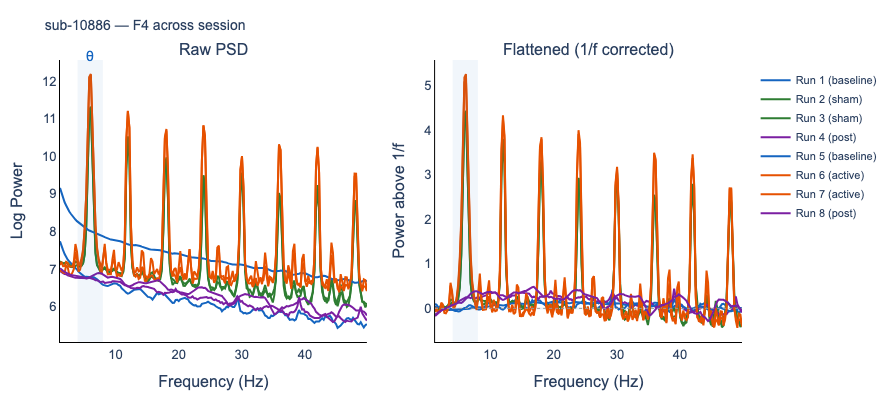

In [40]:
# =============================================================================
# 5. Cross-Run PSD Comparison (F4 focus)
# =============================================================================

condition_colors = {
    'baseline': '#1565C0',
    'sham':     '#2E7D32',
    'active':   '#E65100',
    'post':     '#7B1FA2',
}

ch_focus = 'F4'

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=['Raw PSD', 'Flattened (1/f corrected)'],
)

for run_num in sorted(all_runs.keys()):
    nic2 = all_runs[run_num]
    condition = nic2['condition']
    color = condition_colors.get(condition, '#999999')
    model = specparam_models.get((run_num, ch_focus))
    
    if model is None:
        continue
    
    mc = get_model_components(model)
    label = f'Run {run_num} ({condition})'
    
    # Raw PSD
    fig.add_trace(go.Scatter(
        x=mc['freqs'], y=mc['power_spectrum'],
        mode='lines', line=dict(color=color, width=2),
        name=label,
        hovertemplate='%{x:.1f} Hz: %{y:.2f}<extra>' + label + '</extra>',
    ), row=1, col=1)
    
    # Flattened
    fig.add_trace(go.Scatter(
        x=mc['freqs'], y=mc['flattened'],
        mode='lines', line=dict(color=color, width=2),
        name=label, showlegend=False,
        hovertemplate='%{x:.1f} Hz: %{y:.3f}<extra>' + label + '</extra>',
    ), row=1, col=2)

for col in [1, 2]:
    fig.add_vrect(x0=4, x1=8, fillcolor='#1565C0', opacity=0.06,
                  line_width=0, row=1, col=col)

# Add theta label manually to avoid Plotly annotation glitch
fig.add_annotation(x=6, y=1.05, xref='x', yref='paper',
                   text='θ', showarrow=False,
                   font=dict(size=14, color='#1565C0'))

fig.add_hline(y=0, line=dict(color='#999999', width=1, dash='dot'),
              row=1, col=2)

fig.update_layout(
    title=dict(text=f'sub-{SUBJECT_ID} — {ch_focus} across session',
               font=dict(size=14)),
    height=400, width=1000,
    template='plotly_white',
    margin=dict(l=60, r=40, t=60, b=50),
    font=dict(family='Arial', size=13),
    legend=dict(x=1.02, y=0.98, font=dict(size=11)),
)

fig.update_xaxes(title_text='Frequency (Hz)', showgrid=False,
                 showline=True, linewidth=1, linecolor='black')
fig.update_yaxes(showgrid=False,
                 showline=True, linewidth=1, linecolor='black')
fig.update_yaxes(title_text='Log Power', row=1, col=1)
fig.update_yaxes(title_text='Power above 1/f', row=1, col=2)

fig.show(config=dict(toImageButtonOptions=dict(
    filename=f'cross_run_psd_sub-{SUBJECT_ID}')))

## 6. Band Power Across Runs

Extract oscillatory power in each canonical frequency band for every run, using the specparam-derived periodic component (i.e., power above the 1/f background). This separates genuine oscillatory changes from broadband power shifts.

Particularly interested in:
- **Theta (4-8 Hz)**: Does theta power change from baseline → active → post?
- **Alpha (8-13 Hz)**: Alpha suppression during task engagement?

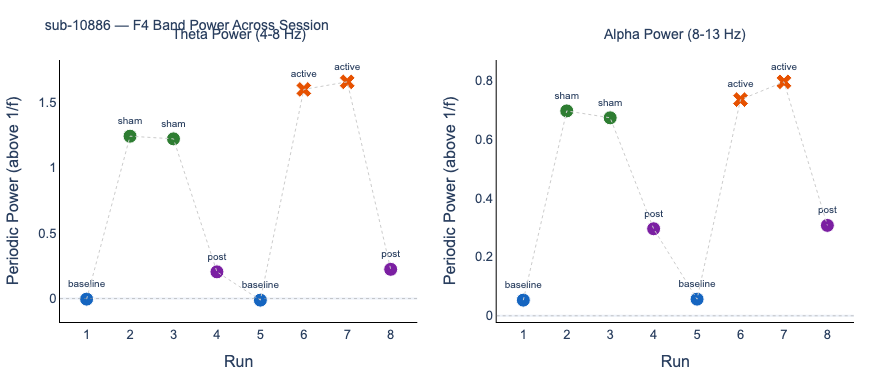


sub-10886 F4 band power summary:
 run condition  is_active_stim  aperiodic_exponent  theta_power  theta_peak  alpha_power  alpha_peak
   1  baseline           False               1.320       -0.004       6.836        0.053      10.254
   2      sham           False               0.532        1.243       6.104        0.696      11.963
   3      sham           False               0.513        1.222       6.104        0.673      11.963
   4      post           False               0.872        0.204       6.104        0.296      10.742
   5  baseline           False               1.482       -0.012       7.812        0.056      12.939
   6    active            True               0.216        1.600       6.104        0.735      11.963
   7    active            True               0.135        1.658       6.104        0.795      11.963
   8      post           False               0.825        0.224       7.812        0.307      10.010


In [43]:
# =============================================================================
# 6. Band Power Across Runs (1/f-corrected)
# =============================================================================

band_power_results = []

for run_num in sorted(all_runs.keys()):
    nic2 = all_runs[run_num]
    condition = nic2['condition']
    is_active = nic2['is_active']
    
    for ch_i, ch_label in enumerate(EEG_CH_LABELS):
        model = specparam_models.get((run_num, ch_label))
        if model is None:
            continue
        
        mc = get_model_components(model)
        freqs = mc['freqs']
        flattened = mc['flattened']
        
        row = {
            'run': run_num,
            'condition': condition,
            'channel': ch_label,
            'is_active_stim': is_active,
            'aperiodic_exponent': mc['ap_params'][1],
        }
        
        for band_name, (f_lo, f_hi) in BANDS.items():
            band_mask = (freqs >= f_lo) & (freqs <= f_hi)
            if np.sum(band_mask) > 0:
                row[f'{band_name}_power'] = np.mean(flattened[band_mask])
                row[f'{band_name}_peak'] = freqs[band_mask][np.argmax(flattened[band_mask])]
        
        band_power_results.append(row)

band_df = pd.DataFrame(band_power_results)

# ---- Plot theta and alpha power across runs (F4) ----
f4_data = band_df[band_df['channel'] == 'F4'].sort_values('run')

fig = make_subplots(rows=1, cols=2,
                    subplot_titles=['Theta Power (4-8 Hz)', 'Alpha Power (8-13 Hz)'])

for col_i, band in enumerate(['theta', 'alpha'], start=1):
    for _, row in f4_data.iterrows():
        color = condition_colors.get(row['condition'], '#999999')
        marker_symbol = 'x' if row['is_active_stim'] else 'circle'
        
        fig.add_trace(go.Scatter(
            x=[row['run']], y=[row[f'{band}_power']],
            mode='markers+text',
            marker=dict(size=14, color=color, symbol=marker_symbol,
                        line=dict(width=1, color='white')),
            text=[row['condition']],
            textposition='top center', textfont=dict(size=10),
            showlegend=False,
            hovertemplate=(f'Run {int(row["run"])} ({row["condition"]})<br>'
                          f'{band} power: %{{y:.3f}}<extra></extra>'),
        ), row=1, col=col_i)
    
    fig.add_trace(go.Scatter(
        x=f4_data['run'], y=f4_data[f'{band}_power'],
        mode='lines', line=dict(color='#CCCCCC', width=1, dash='dot'),
        showlegend=False, hoverinfo='skip',
    ), row=1, col=col_i)
    
    fig.add_hline(y=0, line=dict(color='#999999', width=0.5, dash='dot'),
                  row=1, col=col_i)

fig.update_layout(
    title=dict(text=f'sub-{SUBJECT_ID} — F4 Band Power Across Session',
               font=dict(size=14)),
    height=380, width=800,
    template='plotly_white',
    margin=dict(l=60, r=40, t=60, b=50),
    font=dict(family='Arial', size=13),
)

fig.update_xaxes(title_text='Run', dtick=1, showgrid=False,
                 showline=True, linewidth=1, linecolor='black')
fig.update_yaxes(title_text='Periodic Power (above 1/f)', showgrid=False,
                 showline=True, linewidth=1, linecolor='black')

for ann in fig.layout.annotations:
    ann.update(font_size=14, y=1.06)

fig.show(config=dict(toImageButtonOptions=dict(
    filename=f'band_power_session_sub-{SUBJECT_ID}')))

print(f'\nsub-{SUBJECT_ID} F4 band power summary:')
cols = ['run', 'condition', 'is_active_stim', 'aperiodic_exponent',
        'theta_power', 'theta_peak', 'alpha_power', 'alpha_peak']
print(f4_data[cols].to_string(index=False, float_format='%.3f'))

## 7. ITF Summary & Export

Summarize the individual theta frequency estimates across baseline runs and export for use in the behavioral analysis notebook.

In [46]:
# =============================================================================
# 7. ITF Summary & Export
# =============================================================================
#
# WHAT WE REPORT:
# - ITF from baseline runs only (no tACS artifact contamination)
# - F4 as primary channel (closest to stim target)
# - Flag if no theta peak detected (participant may not have
#   prominent resting theta, which is a real individual difference)
# - Average across baseline runs if multiple are available

# Filter to baseline runs, non-active stim
baseline_itf = specparam_df[
    (specparam_df['condition'].isin(['baseline'])) &
    (~specparam_df['is_active_stim'])
].copy()

print(f'sub-{SUBJECT_ID} — Baseline ITF Estimates')
print('=' * 50)

for ch_label in EEG_CH_LABELS:
    ch_data = baseline_itf[baseline_itf['channel'] == ch_label]
    
    if len(ch_data) == 0:
        print(f'  {ch_label}: No baseline data')
        continue
    
    has_theta = ch_data['has_theta'].any()
    if has_theta:
        theta_runs = ch_data[ch_data['has_theta']]
        mean_itf = theta_runs['itf'].mean()
        mean_power = theta_runs['power'].mean()
        print(f'  {ch_label}: ITF = {mean_itf:.2f} Hz '
              f'(power = {mean_power:.3f}, '
              f'from {len(theta_runs)} baseline run(s))')
    else:
        print(f'  {ch_label}: No theta peak detected in '
              f'{len(ch_data)} baseline run(s)')

# Distance from stimulation frequency
f4_baseline = baseline_itf[
    (baseline_itf['channel'] == 'F4') & (baseline_itf['has_theta'])
]

if len(f4_baseline) > 0:
    itf_mean = f4_baseline['itf'].mean()
    distance = abs(itf_mean - TACS_FREQ)
    print(f'\n  F4 ITF mean: {itf_mean:.2f} Hz')
    print(f'  Distance from tACS frequency ({TACS_FREQ} Hz): {distance:.2f} Hz')
    print(f'  Interpretation: {"close" if distance < 1.5 else "moderate" if distance < 3 else "far"} '
          f'match to stimulation frequency')
else:
    print(f'\n  No theta peak detected in F4 baseline — '
          f'ITF cannot be estimated for this participant')

# Earclip caveat
if not has_earclip:
    print(f'\n  ⚠ CAVEAT: Recorded without Earclip reference. '
          f'ITF estimated from 3-channel avg re-referenced data. '
          f'Treat as approximate.')

sub-10886 — Baseline ITF Estimates
  F4: No theta peak detected in 2 baseline run(s)
  P4: ITF = 6.59 Hz (power = 0.241, from 1 baseline run(s))
  P3: No theta peak detected in 2 baseline run(s)

  No theta peak detected in F4 baseline — ITF cannot be estimated for this participant

  ⚠ CAVEAT: Recorded without Earclip reference. ITF estimated from 3-channel avg re-referenced data. Treat as approximate.


## Summary: What This Notebook Does

### Section 2: Batch Loading & Protocol Verification

We load the raw EEG files from the Starstim device for every run in a participant's session. Each run gets tagged with its expected condition (baseline, sham, active, or post) based on the counterbalance order assigned to that participant. Then we check whether the electrical signal actually matches the expected condition — specifically, we look for the 6 Hz "fingerprint" of tACS in the data. This is essentially asking: "Did the device actually do what we told it to do?" If a run labeled "sham" shows sustained stimulation, we'd catch it here.

### Section 2b: Time-Resolved Stimulation Verification

This is the more detailed version of that check. Instead of looking at the whole run as one summary number, we track the 6 Hz signal strength second by second across the full 6 minutes. This is what let us confirm that the sham runs show a brief burst of stimulation at the beginning (the ramp that mimics the active sensation for blinding purposes) and then nothing for the remaining 5+ minutes, while active runs show sustained stimulation throughout. Think of it like a heart rate monitor for the stimulation — you can see exactly when current was flowing.

### Section 3: Spectral Parameterization (ITF Extraction)

This is where we try to identify each participant's natural theta rhythm. The raw EEG signal contains a mix of different brain rhythms (theta, alpha, beta, etc.) riding on top of a background "noise" pattern where slower frequencies are always louder than faster ones (the 1/f slope). The challenge is that if you just look for the loudest frequency in the theta range (4–8 Hz), you'll almost always find it right at 4 Hz — not because the brain has a strong 4 Hz rhythm, but because the background noise is loudest at the lowest frequencies. Spectral parameterization (specparam) solves this by first fitting and removing the background noise pattern, then looking for genuine rhythmic peaks that stick up above it. If a participant has a real theta oscillation — say at 6.5 Hz — it will appear as a bump above the noise floor after this correction. The center of that bump is their Individual Theta Frequency (ITF).

### Section 4: Specparam Model Fits

This is the visual quality check on the spectral parameterization. For every run and every electrode, we plot three things: the raw signal (black), the fitted background noise pattern (red dashed), and the full model including detected peaks (blue). You can visually verify whether the model is doing a sensible job — is the red line following the overall trend? Are the blue peaks landing on real bumps or fitting noise? On active stimulation runs, you'll see the model trying to fit the massive artificial 6 Hz spike and its harmonics, which is expected and not meaningful for neural interpretation.

### Section 5: Cross-Run PSD Comparison

This collapses all 8 runs onto a single plot for F4 (the frontal electrode closest to our stimulation target). The left panel shows the raw signal strength at each frequency, color-coded by condition. The right panel shows the same data after removing the background noise (the "flattened" spectrum). This lets you directly compare: does the spectrum look different during active stimulation vs sham? What about before vs after stimulation? In the flattened view, only genuine rhythmic peaks and stimulation artifact remain, making differences between conditions much easier to spot.

### Section 6: Band Power Across the Session

This takes the flattened spectra and computes a single number representing how much rhythmic power exists in the theta band (4–8 Hz) and the alpha band (8–13 Hz), above and beyond the background noise. Plotting these across the 8 runs gives a trajectory of the whole session: baseline → first stimulation block → post → second baseline → second stimulation block → final post. This is where you'd see things like whether theta power is elevated after active stimulation compared to after sham (an after-effect), or whether alpha changes with task fatigue across the session.

### Section 7: ITF Summary

This pulls together the individual theta frequency estimates from baseline runs only (where there's no stimulation artifact to confuse things). It reports whether each electrode shows a detectable theta peak, what frequency it's at, and how far that frequency is from our 6 Hz stimulation frequency. The distance matters because tACS is thought to work best when the stimulation frequency is close to the brain's natural rhythm — like pushing a swing in time with its natural arc versus against it.

### Key Limitations

- **No Earclip reference** for first 4 participants: software average re-referencing applied across only 3 EEG-only channels, which introduces mathematical dependencies and can attenuate or create apparent spatial differences between channels. ITF estimates from these participants should be treated as approximate.
- **Stimulation channels blanked**: F3 (the actual stimulation target) is not available for EEG analysis on any run. F4 serves as a proxy based on bilateral symmetry of frontal theta generators.
- **Sham ramp artifact**: Even brief sham ramps produce detectable 6 Hz power in whole-run PSDs. Time-resolved analysis (Section 2b) is necessary to distinguish sham from active stimulation.
- **Task markers absent**: LSL event triggers are not reaching the NIC2 trigger channel, preventing event-locked EEG analyses until the pipeline is fixed.